In [1]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")

In [2]:
np.random.seed(42)

rows = 300

cgpa = np.round(np.random.uniform(5.5,10.0,rows),2)
attendance = np.random.randint(55,100,rows)
internship = np.random.choice(["Yes","No"],rows,p=[0.4,0.6])
programming = np.random.randint(40,100,rows)
communication = np.random.randint(40,100,rows)
aptitude = np.random.randint(40,100,rows)
projects = np.random.randint(1,6,rows)

placement = []

for i in range(rows):

    score = 0

    if cgpa[i] >= 7:
        score += 1

    if attendance[i] >= 75:
        score += 1

    if internship[i] == "Yes":
        score += 1

    if programming[i] >= 65:
        score += 1

    if communication[i] >= 65:
        score += 1

    if aptitude[i] >= 65:
        score += 1

    if projects[i] >= 3:
        score += 1

    if score >= 5:
        placement.append("Yes")
    else:
        placement.append("No")


df = pd.DataFrame({

    "CGPA":cgpa,
    "Attendance":attendance,
    "Internship":internship,
    "ProgrammingSkill":programming,
    "CommunicationSkill":communication,
    "AptitudeScore":aptitude,
    "Projects":projects,
    "Placement":placement

})

df.head()

,CGPA,Attendance,Internship,ProgrammingSkill,CommunicationSkill,AptitudeScore,Projects,Placement
0,7.19,99,No,74,41,90,4,Yes
1,9.78,86,No,91,92,97,1,Yes
2,8.79,84,Yes,64,48,42,3,No
3,8.19,89,Yes,65,48,95,5,Yes
4,6.20,94,Yes,50,79,79,3,Yes


In [3]:
df.to_csv("student_placement_dataset.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [4]:
print(df.shape)

df.info()

(300, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CGPA                300 non-null    float64
 1   Attendance          300 non-null    int64  
 2   Internship          300 non-null    object 
 3   ProgrammingSkill    300 non-null    int64  
 4   CommunicationSkill  300 non-null    int64  
 5   AptitudeScore       300 non-null    int64  
 6   Projects            300 non-null    int64  
 7   Placement           300 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 18.9+ KB


In [5]:
df.isnull().sum()

,0
CGPA,0
Attendance,0
Internship,0
ProgrammingSkill,0
CommunicationSkill,0
AptitudeScore,0
Projects,0
Placement,0


In [6]:
df.describe()

,CGPA,Attendance,ProgrammingSkill,CommunicationSkill,AptitudeScore,Projects
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7.728200,77.260000,70.573333,70.280000,69.590000,3.073333
std,1.324661,12.510827,17.024416,17.513347,16.673991,1.421745
min,5.520000,55.000000,40.000000,40.000000,40.000000,1.000000
25%,6.577500,66.000000,58.000000,55.000000,55.750000,2.000000
50%,7.800000,78.000000,71.000000,71.000000,69.000000,3.000000
75%,8.905000,88.000000,86.000000,85.000000,83.250000,4.000000
max,9.960000,99.000000,99.000000,99.000000,99.000000,5.000000


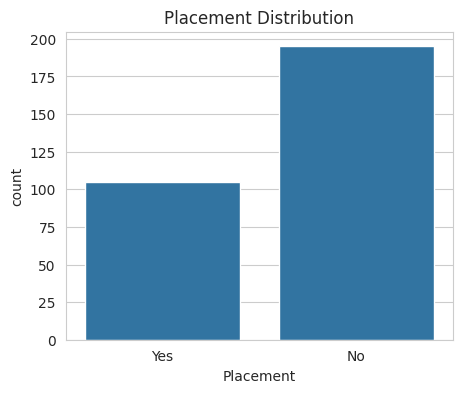

In [7]:
plt.figure(figsize=(5,4))

sns.countplot(x="Placement",data=df)

plt.title("Placement Distribution")

plt.show()

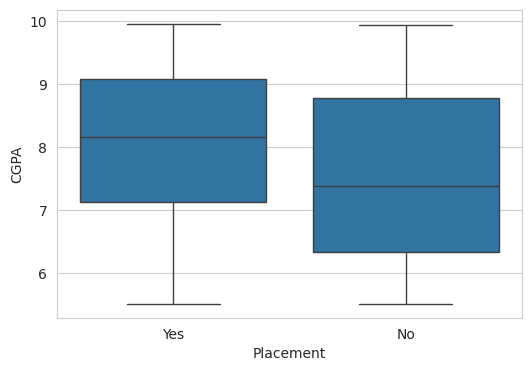

In [8]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Placement",y="CGPA",data=df)

plt.show()

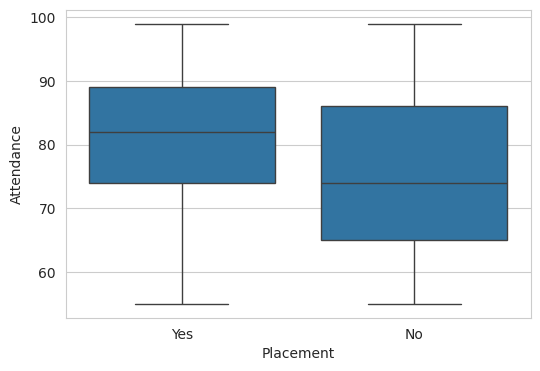

In [9]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Placement",y="Attendance",data=df)

plt.show()

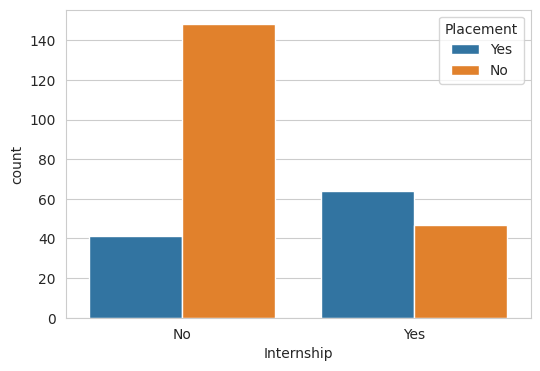

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="Internship",hue="Placement",data=df)

plt.show()

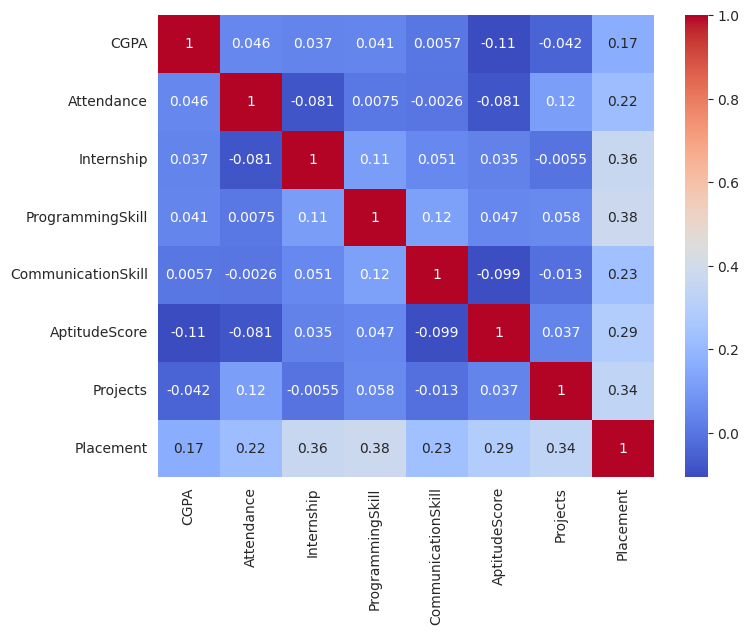

In [11]:
temp = df.copy()

encoder = LabelEncoder()

temp["Internship"] = encoder.fit_transform(temp["Internship"])

temp["Placement"] = encoder.fit_transform(temp["Placement"])

plt.figure(figsize=(8,6))

sns.heatmap(temp.corr(),annot=True,cmap="coolwarm")

plt.show()

In [12]:
encoder = LabelEncoder()

df["Internship"] = encoder.fit_transform(df["Internship"])

df["Placement"] = encoder.fit_transform(df["Placement"])

In [13]:
X = df.drop("Placement",axis=1)

y = df["Placement"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

In [15]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy)

Accuracy = 0.9333333333333333


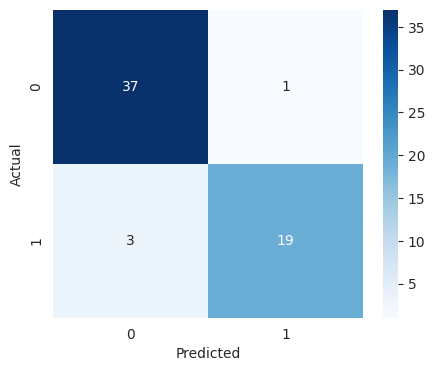

In [18]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        38
           1       0.95      0.86      0.90        22

    accuracy                           0.93        60
   macro avg       0.94      0.92      0.93        60
weighted avg       0.93      0.93      0.93        60



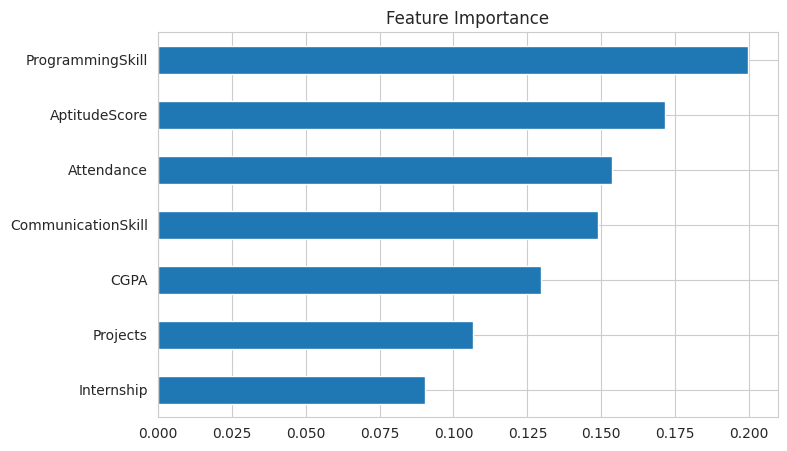

In [20]:
importance = pd.Series(model.feature_importances_,index=X.columns)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()

In [21]:
print("Top Important Features")

print(importance.sort_values(ascending=False))

Top Important Features
ProgrammingSkill      0.199653
AptitudeScore         0.171492
Attendance            0.153682
CommunicationSkill    0.148760
CGPA                  0.129683
Projects              0.106490
Internship            0.090239
dtype: float64
